# 1 
Estamos interesados en la proporción de éxito 𝜃 de una distribución Bernoulli. Tenemos una
muestra observada que consiste en el número de éxitos en 30 ensayos independientes y con idéntica distribución de una Bernoulli con parámetro 𝜃; en esta muestra hay precisamente 19 éxitos.
- (a) Definir una grilla de posibles valores para 𝜃
Calcular la verosimilitud para cada valor de la grilla.
- (c) Suponiendo una prior uniforme sobre 𝜃, calcular la distribución posterior no normalizada y
luego normalizar.
- (d) Graficar la distribución posterior obtenida y comparar con la distribución posterior teórica,
que es una Beta.
- (e) Samplear la distribución posterior y dar: 𝑃 (𝜃 < 0.5), 𝑃 (0.5 < 𝜃 < 0.75), el intervalo percentil
central del 90% y el 90% HPDI
- (f ) Samplear la posterior predictiva y dar el 90% HPDI.
- (g) Calcular para cada 𝑘 la probabilidad de obtener 𝑘 éxitos en 10 experimentos con la posterior
predictiva. ¿Se trata ésta de una distribución binomial?


In [14]:
#a  Grilla de posibles valores para 𝜃

import numpy as np

grilla_theta = np.linspace(0,1,1000)

In [15]:
# b calcular verosimilitud likelihood
from scipy.stats import binom

n = 30 # ensayos
y = 19 # exitos

# evalua la funcion de mesa de probabilidad PMFde la binom
likelihood_theta = binom.pmf(y, n, grilla_θ)

In [22]:
# prior uniforme sobre 𝜃 calcular la dis posterior no normalizada y luego normarlizar

from scipy.stats import uniform
prior = uniform.pdf(grilla_theta)

# Posterior no normalizada
posterior = likelihood_theta * prior

# Posterior normalizada
posterior /= np.trapz(posterior, grilla_theta)
 #ref https://numpy.org/doc/1.21/reference/generated/numpy.trapz.html

In [23]:
import numpy as np

print(np.__version__)
print(np.__path__)

1.26.4
['C:\\tools\\Manim\\Lib\\site-packages\\numpy']


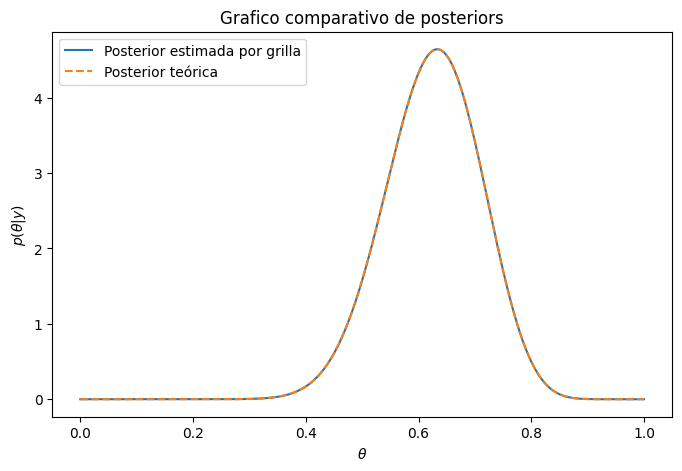

In [24]:
# graficiar  la distirbucion posterior y comparar con la distribucion posterior teorica que es beta
import matplotlib.pyplot as plt
from scipy.stats import beta

# Defino posterior teorica
posterior_teorica = beta.pdf(grilla_theta, y+1, n-y+1)

# Hago el gráfico comparativo
plt.figure(figsize=(8, 5))
plt.plot(grilla_theta, posterior, label='Posterior estimada por grilla')
plt.plot(grilla_theta, posterior_teorica, '--' ,label='Posterior teórica')
plt.title('Grafico comparativo de posteriors')
plt.ylabel(r'$p(\theta|y)$')
plt.xlabel(r'$\theta$')
plt.legend()
plt.show()

In [27]:
# samplear la distribucion posterior y dar  pprobabilidades , el Intervalo percenctialen 90% y 90 HPDI
samples_posterior = np.random.choice(grilla_theta, size=10000, p= posterior / np.sum(posterior))

print(f'P(theta < 0.5): {np.mean(samples_posterior < 0.5)}')
print(f'P(0.5 < theta < 0.75): {np.mean((0.5 < samples_posterior) & (samples_posterior < 0.75))}')

#intervalo
print(f'Intervalo Percentil 90%: {np.percentile(samples_posterior, [5, 95])}')


import arviz as az

print(f'90% HDPI: {az.hdi(samples_posterior, hdi_prob=0.9)}')

P(theta < 0.5): 0.0729
P(0.5 < theta < 0.75): 0.8596
Intervalo Percentil 90%: [0.48448448 0.76176176]
90% HDPI: [0.49449449 0.77077077]


In [29]:
# f samplear el anteior
samples_post_predictive = binom.rvs(n = 30, p = samples_posterior, size = 10000)

print(f'Posterior predictiva 90& HDPI: {az.hdi(samples_post_predictive, hdi_prob=0.9)}')

Posterior predictiva 90& HDPI: [12 24]


In [30]:
# Calcular para cada 𝑘 la probabilidad de obtener 𝑘 éxitos en 10 experimentos con la posterior predictiva. 
# ¿Se trata ésta de una distribución binomial?
exps_post_predictive = binom.rvs(n = 10, p = samples_posterior, size = 10000)

for i in range(10 + 1):
    print(f'P(y = {i}): {np.mean(exps_post_predictive == i)}')

P(y = 0): 0.0001
P(y = 1): 0.0037
P(y = 2): 0.0164
P(y = 3): 0.0465
P(y = 4): 0.0962
P(y = 5): 0.1671
P(y = 6): 0.2132
P(y = 7): 0.2096
P(y = 8): 0.1569
P(y = 9): 0.0723
P(y = 10): 0.018


No es una distribucion binomail ya que integra por sobre todos los thetas psobiles de acuerdo a la posterior


<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>p</mi>
  <mo stretchy="false">(</mo>
  <mrow data-mjx-texclass="ORD">
    <mover>
      <mi>y</mi>
      <mo stretchy="false">~</mo>
    </mover>
  </mrow>
  <mo data-mjx-texclass="ORD" stretchy="false">|</mo>
  <mi>y</mi>
  <mo stretchy="false">)</mo>
  <mo>=</mo>
  <msubsup>
    <mo data-mjx-texclass="OP">&#x222B;</mo>
    <mn>0</mn>
    <mn>1</mn>
  </msubsup>
  <mi>p</mi>
  <mo stretchy="false">(</mo>
  <mrow data-mjx-texclass="ORD">
    <mover>
      <mi>y</mi>
      <mo stretchy="false">~</mo>
    </mover>
  </mrow>
  <mo data-mjx-texclass="ORD" stretchy="false">|</mo>
  <mi>y</mi>
  <mo>,</mo>
  <mi>&#x3B8;</mi>
  <mo stretchy="false">)</mo>
  <mi>p</mi>
  <mo stretchy="false">(</mo>
  <mi>&#x3B8;</mi>
  <mo data-mjx-texclass="ORD" stretchy="false">|</mo>
  <mi>y</mi>
  <mo stretchy="false">)</mo>
  <mi>d</mi>
  <mi>&#x3B8;</mi>
</math>

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>p</mi>
  <mo stretchy="false">(</mo>
  <mrow data-mjx-texclass="ORD">
    <mover>
      <mi>y</mi>
      <mo stretchy="false">~</mo>
    </mover>
  </mrow>
  <mo data-mjx-texclass="ORD" stretchy="false">|</mo>
  <mi>y</mi>
  <mo stretchy="false">)</mo>
  <mo>=</mo>
  <msubsup>
    <mo data-mjx-texclass="OP">&#x222B;</mo>
    <mn>0</mn>
    <mn>1</mn>
  </msubsup>
  <mi>p</mi>
  <mo stretchy="false">(</mo>
  <mrow data-mjx-texclass="ORD">
    <mover>
      <mi>y</mi>
      <mo stretchy="false">~</mo>
    </mover>
  </mrow>
  <mo data-mjx-texclass="ORD" stretchy="false">|</mo>
  <mi>&#x3B8;</mi>
  <mo stretchy="false">)</mo>
  <mi>p</mi>
  <mo stretchy="false">(</mo>
  <mi>&#x3B8;</mi>
  <mo data-mjx-texclass="ORD" stretchy="false">|</mo>
  <mi>y</mi>
  <mo stretchy="false">)</mo>
  <mi>d</mi>
  <mi>&#x3B8;</mi>
</math>

Por ser los dos experimentos independientes dado theta
<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>p</mi>
  <mo stretchy="false">(</mo>
  <mrow data-mjx-texclass="ORD">
    <mover>
      <mi>y</mi>
      <mo stretchy="false">~</mo>
    </mover>
  </mrow>
  <mo data-mjx-texclass="ORD" stretchy="false">|</mo>
  <mi>y</mi>
  <mo stretchy="false">)</mo>
  <mo>=</mo>
  <msubsup>
    <mo data-mjx-texclass="OP">&#x222B;</mo>
    <mn>0</mn>
    <mn>1</mn>
  </msubsup>
  <mi>B</mi>
  <mi>i</mi>
  <mo stretchy="false">(</mo>
  <mrow data-mjx-texclass="ORD">
    <mover>
      <mi>y</mi>
      <mo stretchy="false">~</mo>
    </mover>
  </mrow>
  <mo data-mjx-texclass="ORD" stretchy="false">|</mo>
  <mi>&#x3B8;</mi>
  <mo>,</mo>
  <mi>n</mi>
  <mo stretchy="false">)</mo>
  <mi>B</mi>
  <mi>e</mi>
  <mi>t</mi>
  <mi>a</mi>
  <mo stretchy="false">(</mo>
  <mi>y</mi>
  <mo>+</mo>
  <mn>1</mn>
  <mo>,</mo>
  <mi>n</mi>
  <mo>&#x2212;</mo>
  <mi>y</mi>
  <mo>+</mo>
  <mn>1</mn>
  <mo stretchy="false">)</mo>
  <mi>d</mi>
  <mi>&#x3B8;</mi>
</math>

y esta expresion define una distirbucion beta-binomiall

